# Intraday curves and relationships between daily variables

The aim of this notebook is to construct average intraday curves for certain market indicators such as volume, number of trades, turnover, volatility, spread, imbalance and liquidity available at best bid and best ask. 

We will then study the relationships between certain daily indicators, such as the links between volume and number of trades, turnover and number of trades, and spread and volatility per trade.e.

## I. Data Extracting

10 databases in `DataFrame` format from `Pandas` are available, one for each asset on 3 different stock exchanges :
* **Paris** : Bouygues, LVMH, Sanofi et Total ;
* **Nasdaq** : Amazon, Apple, Google ;
* **Tokyo** : Canon, Panasonic et Sony.


Each `DataFrame` presents all transactions for the year 2011 for the asset and has the same format: 
* the `Time` index is the transaction timestamp;
* the `TradedPrice` column represents the average price per share of the transaction;
* the `TradedQty` column represents the transaction volume;
* the `BidPrice` column represents the best bid price just prior to the transaction;
* the `AskPrice` column represents the best ask price just before the transaction;
* the `BidQty` column represents the best bid volume just before the transaction;
* the `AskQty` column represents the best ask volume just before the transaction;
* the `TradedSign` column represents the sign of the transaction (negative for bid and positive for ask).ur ask).

In [1]:
import warnings 
warnings.filterwarnings("ignore")

In [2]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install --upgrade pip
!pip install tables
!pip install pytables


[notice] A new release of pip is available: 23.2.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for pip from https://files.pythonhosted.org/packages/15/aa/3f4c7bcee2057a76562a5b33ecbd199be08cdb4443a02e26bd2c3cf6fc39/pip-23.3.2-py3-none-any.whl.metadata
  Using cached pip-23.3.2-py3-none-any.whl.metadata (3.5 kB)
Using cached pip-23.3.2-py3-none-any.whl (2.1 MB)


ERROR: To modify pip, please run the following command:
C:\Users\hamza\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement pytables (from versions: none)
ERROR: No matching distribution found for pytables

[notice] A new release of pip is available: 23.2.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import datetime as dt
import os 
import matplotlib.dates as md
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
import seaborn as sns
import scipy
from matplotlib.legend import Legend

In [4]:
# Listing date files
companies=os.listdir("Data")

#extracting companies' names
companies=[ x[:-3] for x in os.listdir("Data")]

# Creating a dataframe of each company
dfs = {}

# access each dataframe using dfs['company_name']
for company in companies:
    dfs[company] = pd.read_hdf('Data/{}.h5'.format(company),parse_dates=True)

In [5]:
# Displaying the first 5 items of the Amazon dataframe
dfs["AMAZON"].head(5)

,TradedPrice,TradedQty,BidPrice,AskPrice,BidQty,AskQty,TradedSign
Time,,,,,,,
2011-01-03 09:30:00.188,181.32,100,181.25,181.35,100,200,0
2011-01-03 09:30:00.188,181.35,100,181.25,181.35,100,200,1
2011-01-03 09:30:00.201,181.35,100,181.25,181.35,100,100,1
2011-01-03 09:30:00.201,181.37,200,181.25,181.38,100,400,0
2011-01-03 09:30:00.201,181.38,100,181.25,181.38,100,400,1


## II. Intraday Curves of different indicators

We draw up intraday curves averaged over the year in 5-minute increments in percentage terms (to compare assets), and made a chart for each stock market with the 3 or 4 assets of each. A comment on the results obtained for each curve (curve shape, peaks, etc.) is in the end of the section.


In [6]:
# Declaring global variables 

Paris =['BOUYGUES', 'LVMH', 'SANOFI', 'TOTAL'] 
Nasdaq =[ 'AMAZON', 'APPLE', 'GOOGLE' ]
Tokyo =['CANON', 'PANASONIC','SONY']

Locations = { "Paris" : Paris,
              "Nasdaq" : Nasdaq,
              "Tokyo" : Tokyo }

OpenCloseTime={ "Paris" : ['09:00:00','17:25:00'],
                "Nasdaq": ['09:30:00','15:59:59'],
                "Tokyo" : ['09:00:00','14:59:55']
              }

In [7]:
#Funtion to plot intraday curves
def plotIntraday(df,title,titley,sizex=15,sizey=8):
    
    locs = list(Locations.keys())
    
    dfloc0= df[locs[0]]
    dfloc1= df[locs[1]]
    dfloc2= df[locs[2]]
    
    fig, axes = plt.subplots(1,3,figsize=(22, 10),constrained_layout=True)
    
    
    dfloc0.index = pd.to_datetime([ x.strftime("%H:%M") for x in dfloc0.index])
    dfloc1.index = pd.to_datetime([ x.strftime("%H:%M") for x in dfloc1.index])
    dfloc2.index = pd.to_datetime([ x.strftime("%H:%M") for x in dfloc2.index])
    
    
    dfloc0.plot(ax=axes[0],drawstyle="steps",linewidth=3)
    dfloc1.plot(ax=axes[1],drawstyle="steps",linewidth=3)
    dfloc2.plot(ax=axes[2],drawstyle="steps",linewidth=3)
    
    ## Set time format and the interval of ticks (every 30 minutes)
    xformatter = md.DateFormatter('%H:%M')
    
    ## Set xtick labels to appear every 30 minutes
    xlocator = md.MinuteLocator(interval = 60)
    
    
    for i in range(len(locs)) :
        axes[i].grid(True)
        axes[i].set_facecolor('xkcd:white')
        axes[i].set_title(locs[i], fontsize=18,fontweight='bold', color="k")
        axes[i].xaxis.set_major_formatter(xformatter)
        axes[i].xaxis.set_major_locator(xlocator)
        axes[i].legend(fancybox=True, framealpha=1, shadow=True, borderpad=1)
        axes[i].autoscale()
    
       
    fig.suptitle(title, fontsize=24, color="darkblue",fontweight='bold')
    fig.supxlabel("Time of the day", fontsize=20, color="k")
    fig.supylabel(titley, fontsize=20, color="k")
    plt.show()



### 1. Volume Curve

In [8]:
def IntradayCurvesVolume(dfs,locations):
    Volumes= {}
    for loc in locations :
        Volume = pd.DataFrame ({key: dfs[key].TradedQty.resample('5T').sum().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1]) for key in Locations[loc]} )
        Volume = 100*Volume.groupby(Volume.index.time).mean()/Volume.sum()
        Volumes[loc]=Volume
    return Volumes

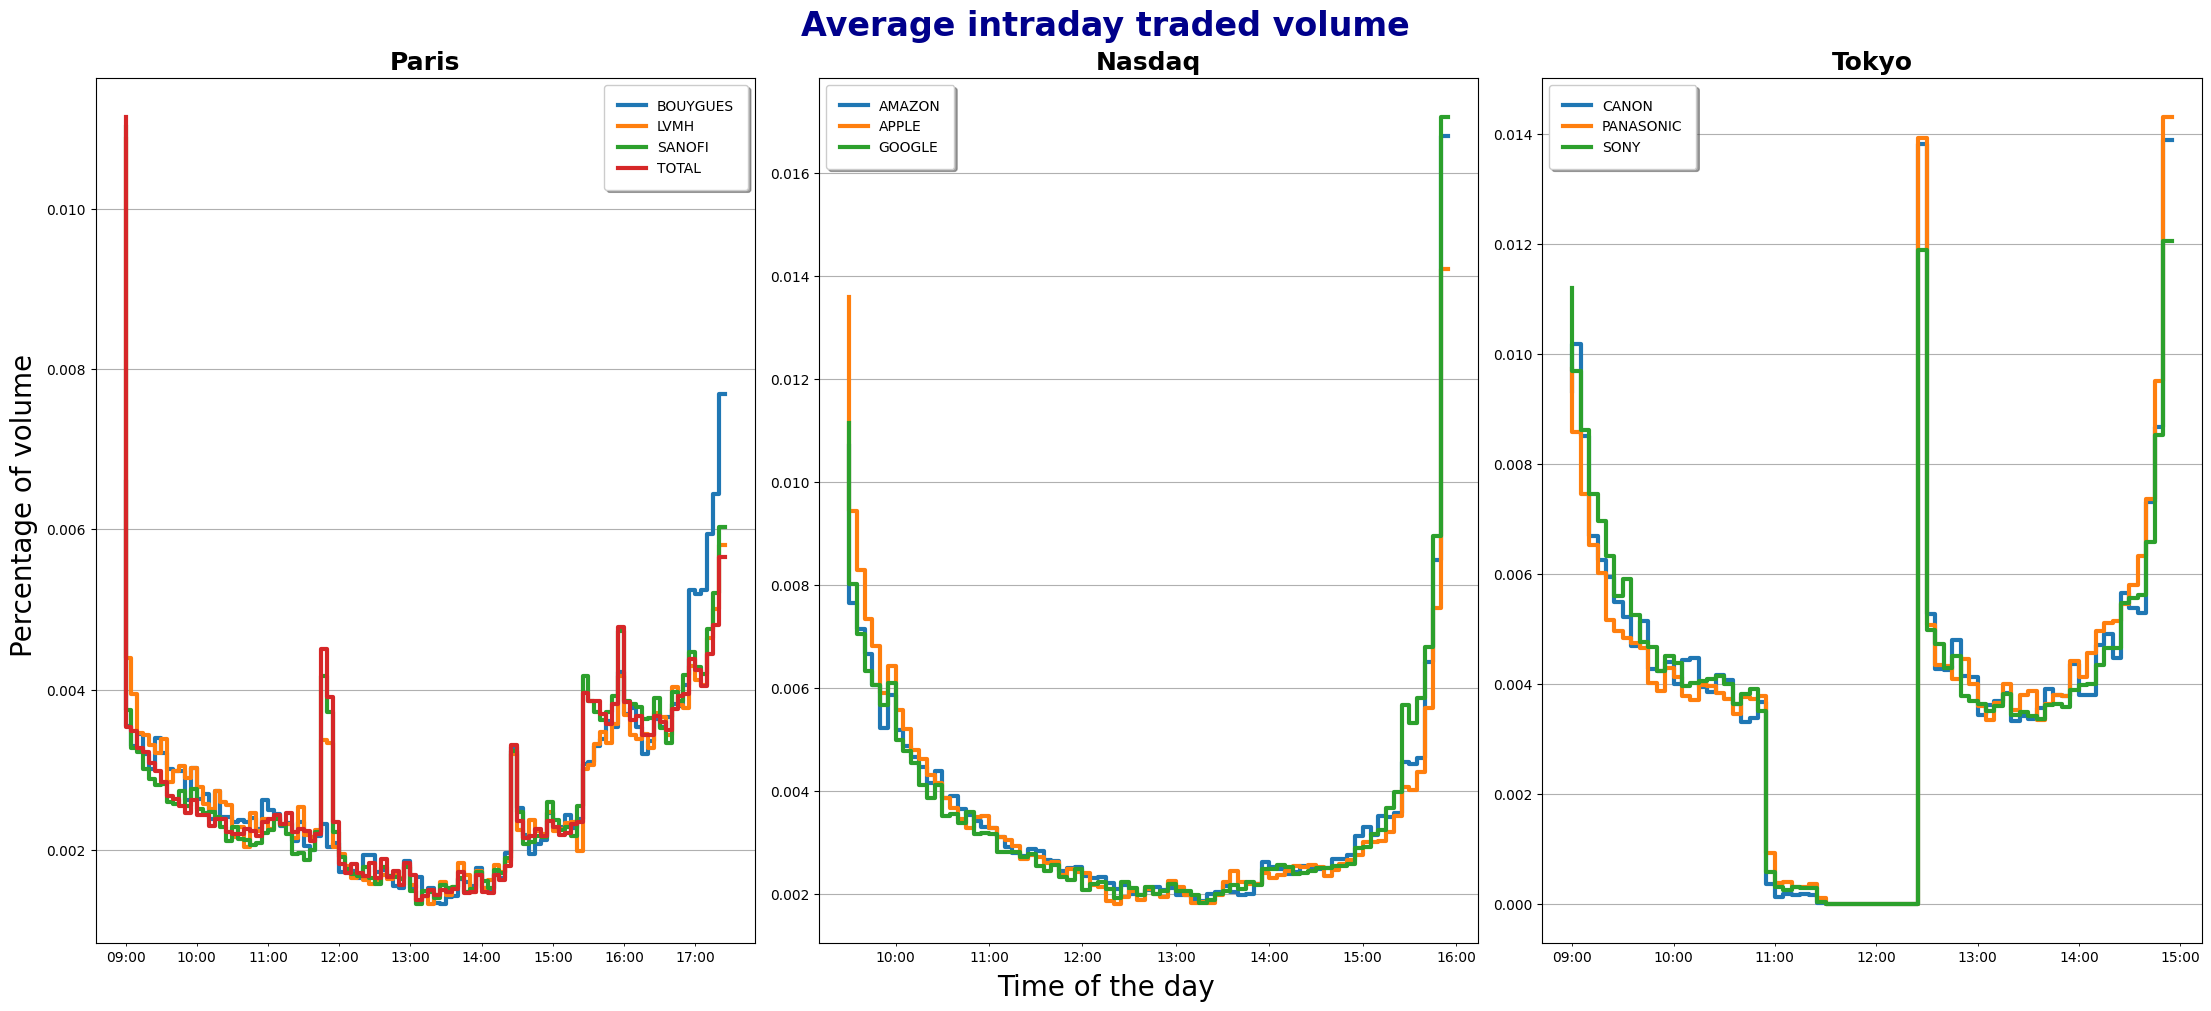

In [9]:
plotIntraday(IntradayCurvesVolume(dfs,Locations.keys()),title='Average intraday traded volume',titley="Percentage of volume")

**Remarks :**

The U or J shape can be explained at the opening and closing:

Volume at the market open is higher, as market players implement their trading strategies. What's more, overnight information can also have an impact on market players' view of the true value of the fair price, and so they adapt their financial positions accordingly.
Also at the close, many of them will seek to unwind their positions, resulting in a race for liquidity and hence a spike in volume.

More specifically:

* **For TSE:** 
It's easy to see that the market comes to a halt during the lunch break (between 11am and 12:30pm), with a peak opening at 12:30pm. We therefore have three peaks: 2 for opening and one for closing (at 4pm).

* **For Paris:** 
There are also peaks at
11am: Publication of short-term interest rates and macroeconomic news by the European Central Bank,
2pm: publication of US macroeconomic news,
3:30 pm: US market opens (Paris local time, i.e. 9:30 am NY time).
~4pm: impact of the EDSP

* **For Nasdaq:**
No exchange opens during its activity, hence its smoother appearance.

### 2. Intraday Curve of the Number of trades

In [10]:
def IntradayCurvesNbTrades(dfs,locations):
    Nbtrades= {}
    for loc in locations :
        Nbtrade = pd.DataFrame ({key: dfs[key].TradedSign.abs().resample('5T').sum().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1]) for key in Locations[loc]} )
        Nbtrade = 100*Nbtrade.groupby(Nbtrade.index.time).mean()/Nbtrade.sum()
        Nbtrades[loc]=Nbtrade
    return Nbtrades
        

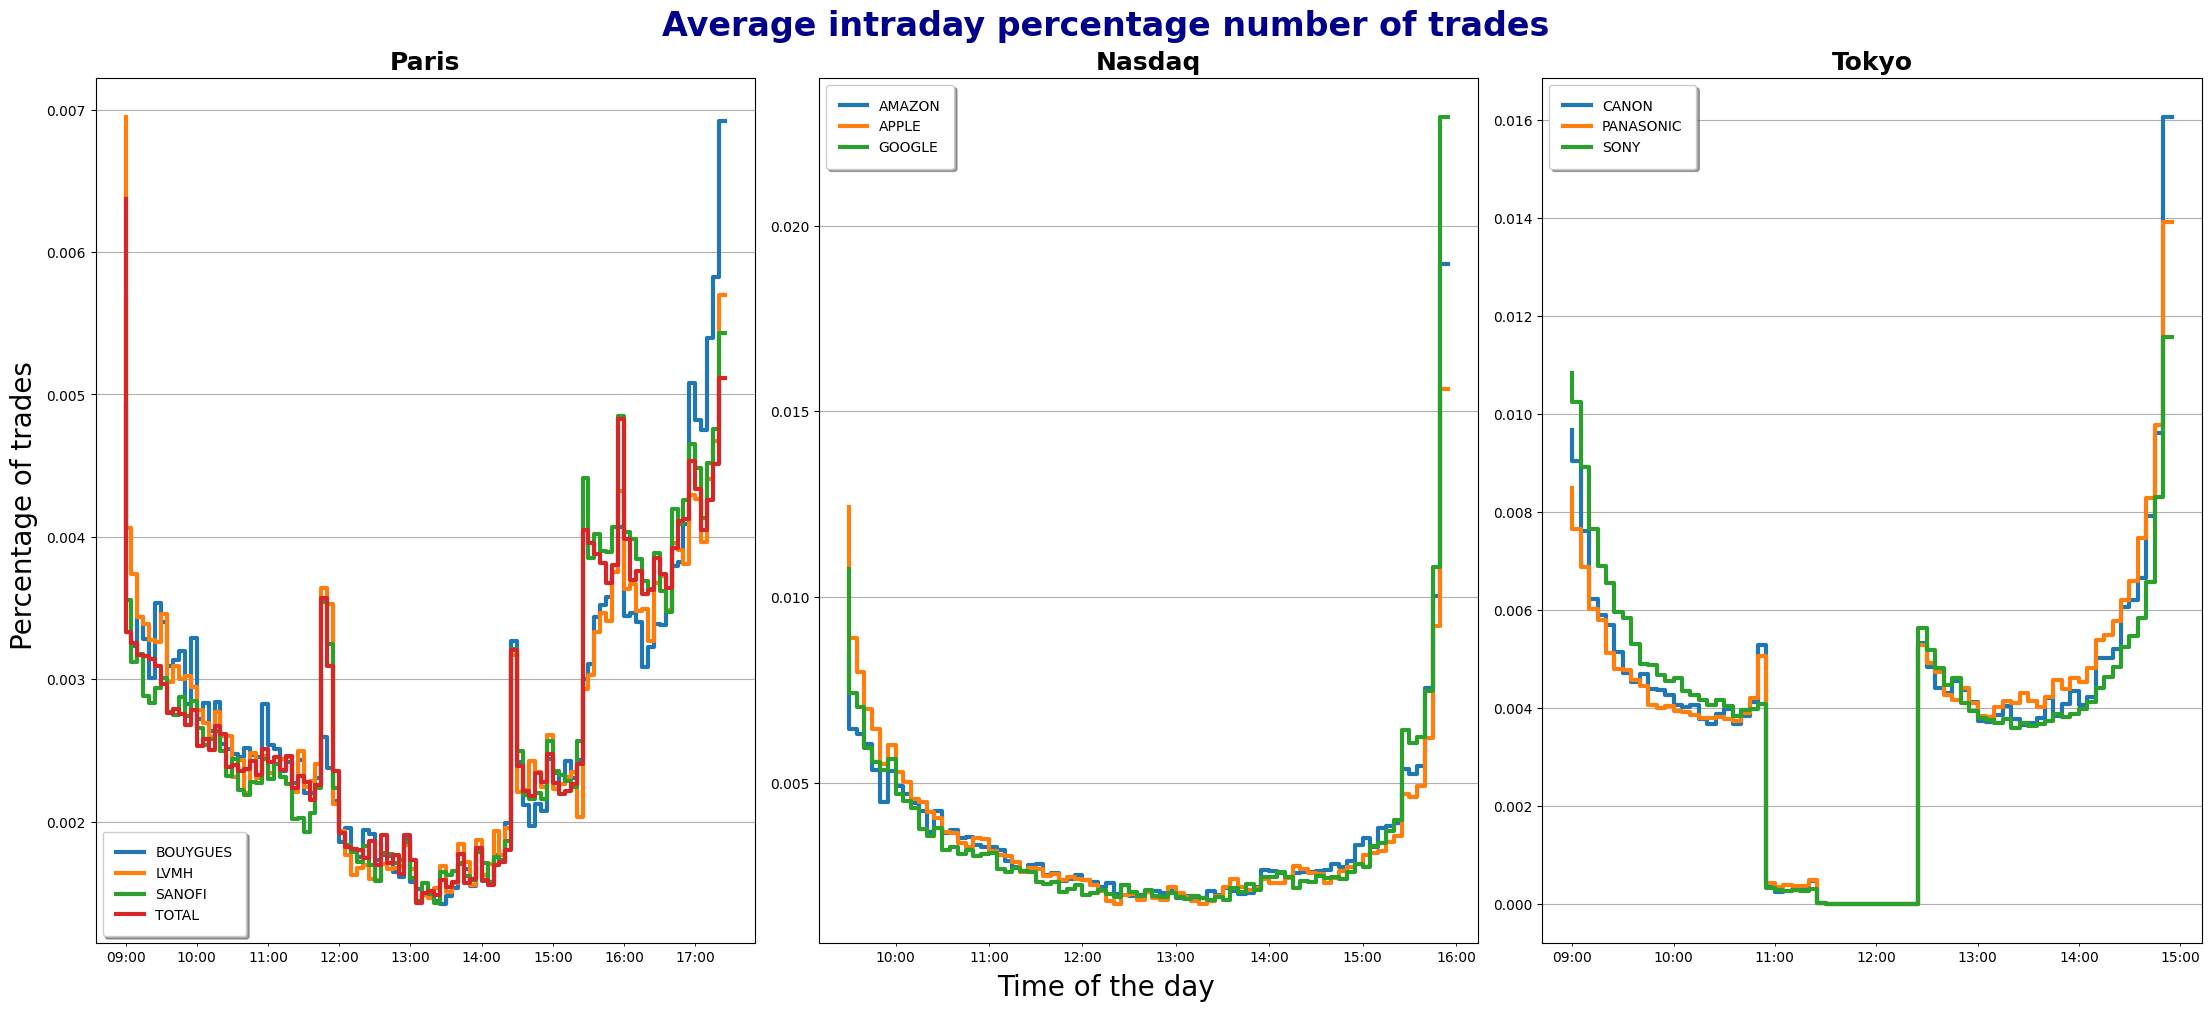

In [11]:
plotIntraday(IntradayCurvesNbTrades(dfs,Locations.keys()),title="Average intraday percentage number of trades",titley="Percentage of trades")

### 3. Turnover Curve (cash)

In [12]:
def IntradayCurvesTurnover(dfs,locations):
    Turnovers= {}
    for loc in locations :
        Turnover = pd.DataFrame ({key: (dfs[key].TradedPrice * dfs[key].TradedQty).resample('5T').sum().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1]) for key in Locations[loc]} )
        Turnover = 100*Turnover.groupby(Turnover.index.time).mean()/Turnover.sum()
        Turnovers[loc]=Turnover
    return Turnovers

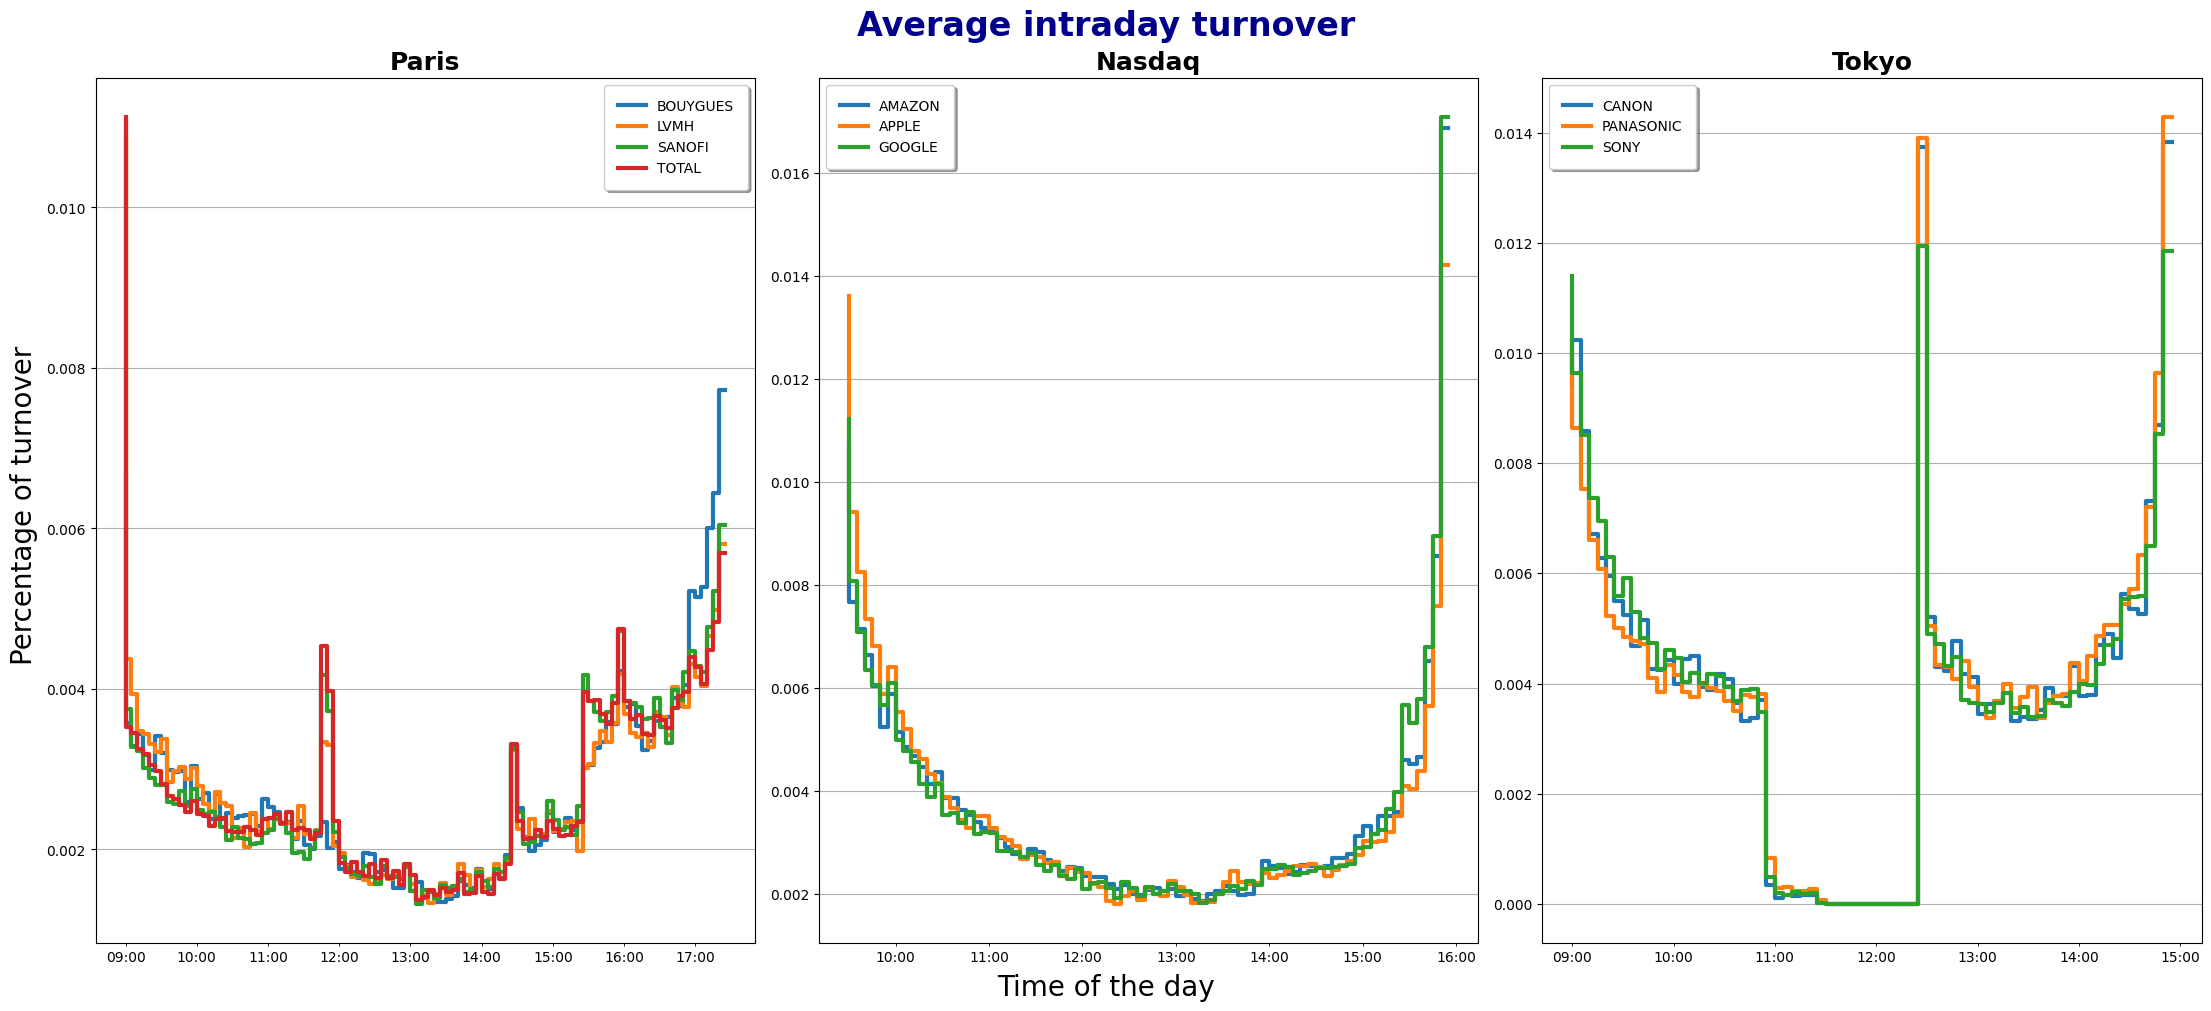

In [13]:
plotIntraday(IntradayCurvesTurnover(dfs,Locations.keys()),title="Average intraday turnover", titley="Percentage of turnover")

### 4. Mean Spread Curve

In [14]:
def IntradayCurvesMeanSpread(dfs,locations):
    Spreads= {}
    for loc in locations :
        Spread = pd.DataFrame ({key: (dfs[key].AskPrice - dfs[key].BidPrice).resample('5T').mean().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1]) for key in Locations[loc]} )
        Spread = 100*Spread.groupby(Spread.index.time).mean()/Spread.sum()
        Spreads[loc]=Spread
    return Spreads

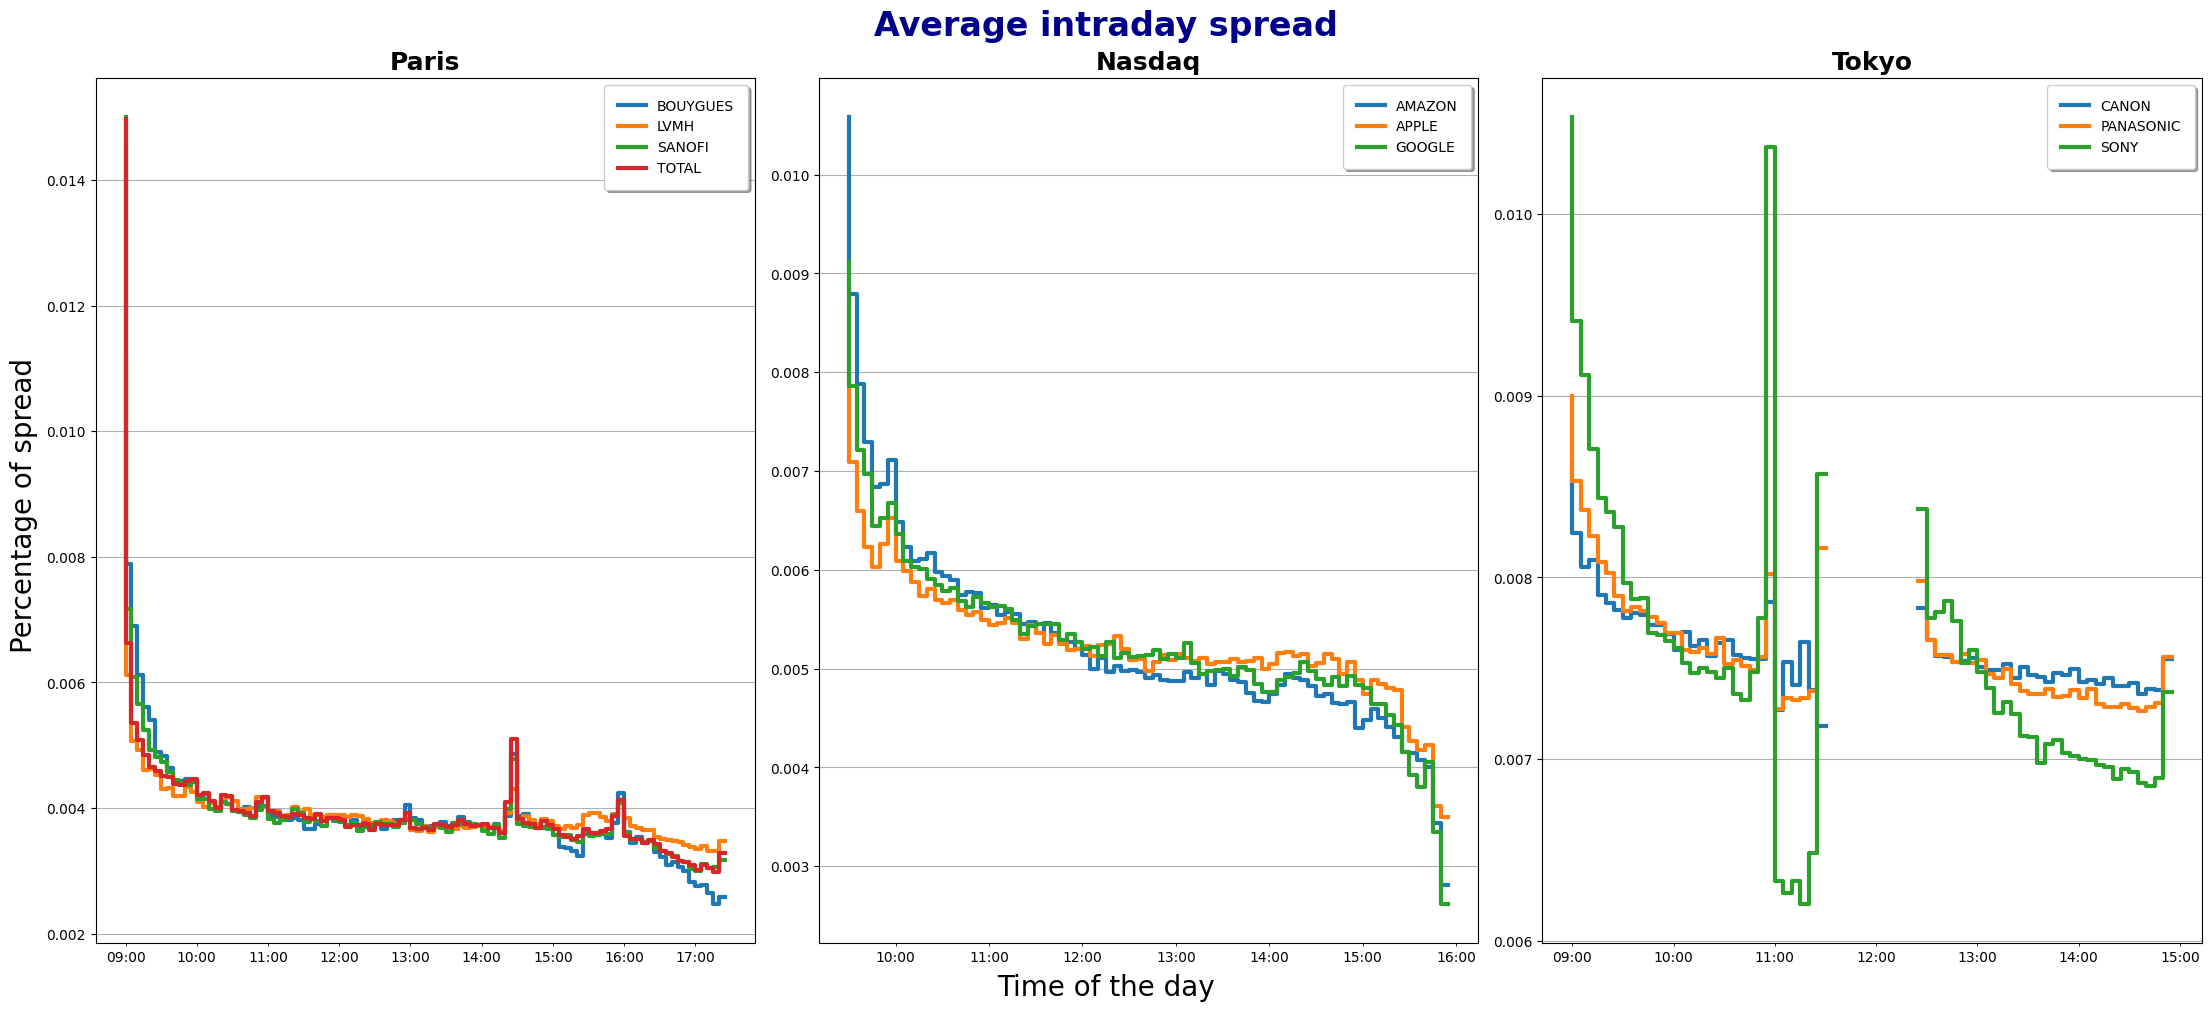

In [15]:
plotIntraday(IntradayCurvesMeanSpread(dfs,Locations.keys()),"Average intraday spread", titley="Percentage of spread")

**Remarks :**

* For the TSE market, the assets are large tick assets, which explains why the spread is less volatile over the day than for the US and EU markets (the spread often being equal to 1 tick).


* For the US and EU markets, mainly small-ticket assets, we have an S-shaped spread curve. At the start of the day, market participants don't have all the information they need to define their fair price, hence the wide spread. At the end of the day, market-makers get rid of their liquidity (to hedge their inventory risk) by inserting a large number of market orders between the best bid and best ask, which reduces the spread. 

### 5. Volatility Curve

In [16]:
def IntradayCurvesVolatility(dfs,locations):
    Volatilities= {}
    for loc in locations :
        Volatility = pd.DataFrame ({key: np.sqrt(((np.log(dfs[key].TradedPrice/dfs[key].TradedPrice.shift(1)))**2).resample('5T').sum().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1])) for key in Locations[loc]} )
        Volatility = Volatility.groupby(Volatility.index.time).mean()
        Volatilities[loc]=Volatility
    return Volatilities

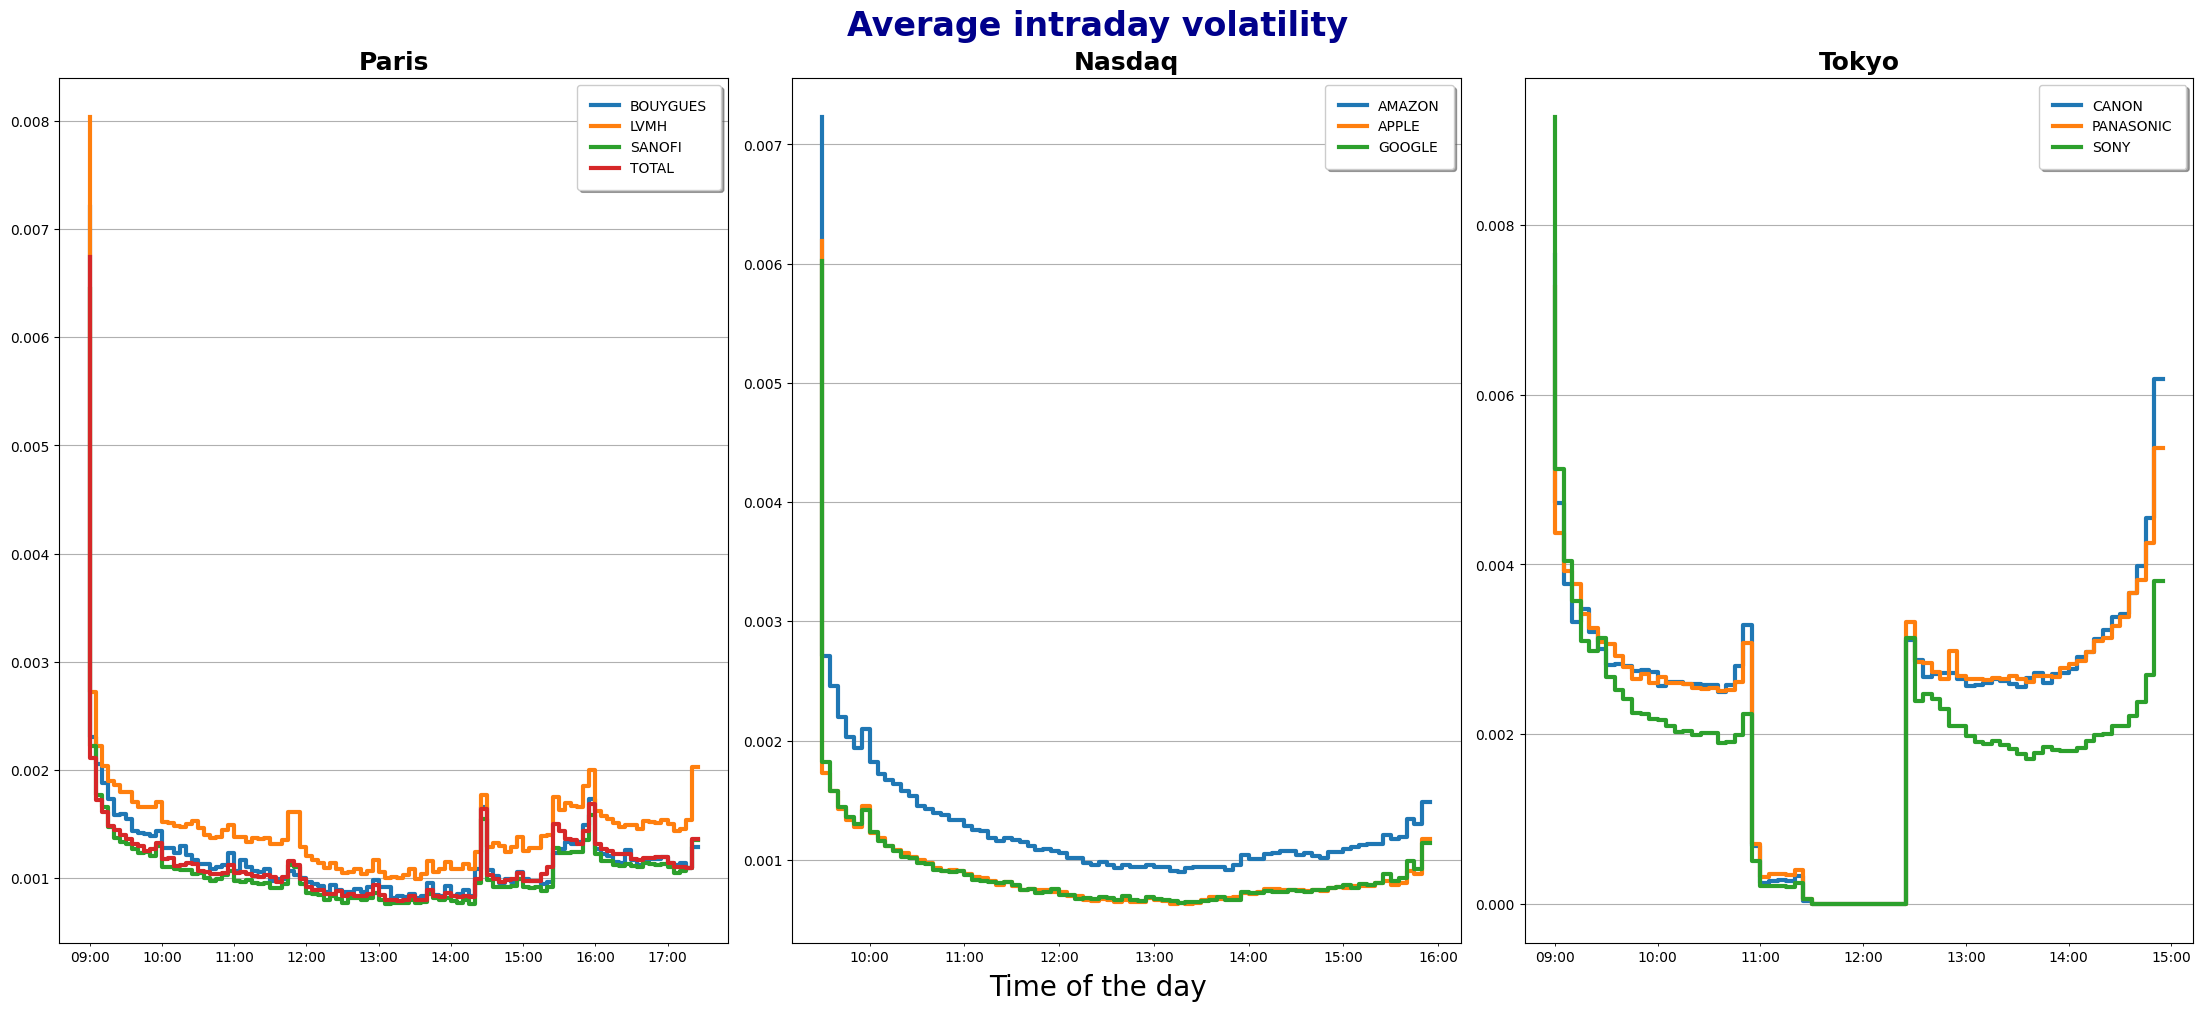

In [17]:
plotIntraday(IntradayCurvesVolatility(dfs,Locations.keys()),"Average intraday volatility", titley="")

**Remark :**

As with the volume curve, we see a U-shape, but more pronounced at the start of the day. There's a big spike at the start of the day, explained by the accumulation of overnight orders. There are also intraday peaks due to the announcement of new information (ECB, US market opening, etc.). Finally, there's a slight increase at the end of the day, synonymous with renewed activity at the end of the day.

### 6. Imbalance Curves (non-signed $|Q_{ask}-Q_{bid}|/(Q_{ask}+Q_{bid})$, signed $(Q_{ask}-Q_{bid})/(Q_{ask}+Q_{bid})$)

In [18]:
def IntradayCurvesImbalance(dfs,locations):
    Imbalances= {}
    for loc in locations :
        num=pd.DataFrame ({key: ( abs(dfs[key].AskQty - dfs[key].BidQty)  ).resample('5T').sum().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1]) for key in Locations[loc]} )
        denum= pd.DataFrame ({key: (  ( dfs[key].AskQty + dfs[key].BidQty ) ).resample('5T').sum().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1]) for key in Locations[loc]} )
        Imbalance = num / denum
        Imbalance = Imbalance.groupby(Imbalance.index.time).mean()
        Imbalances[loc]=Imbalance
    return Imbalances

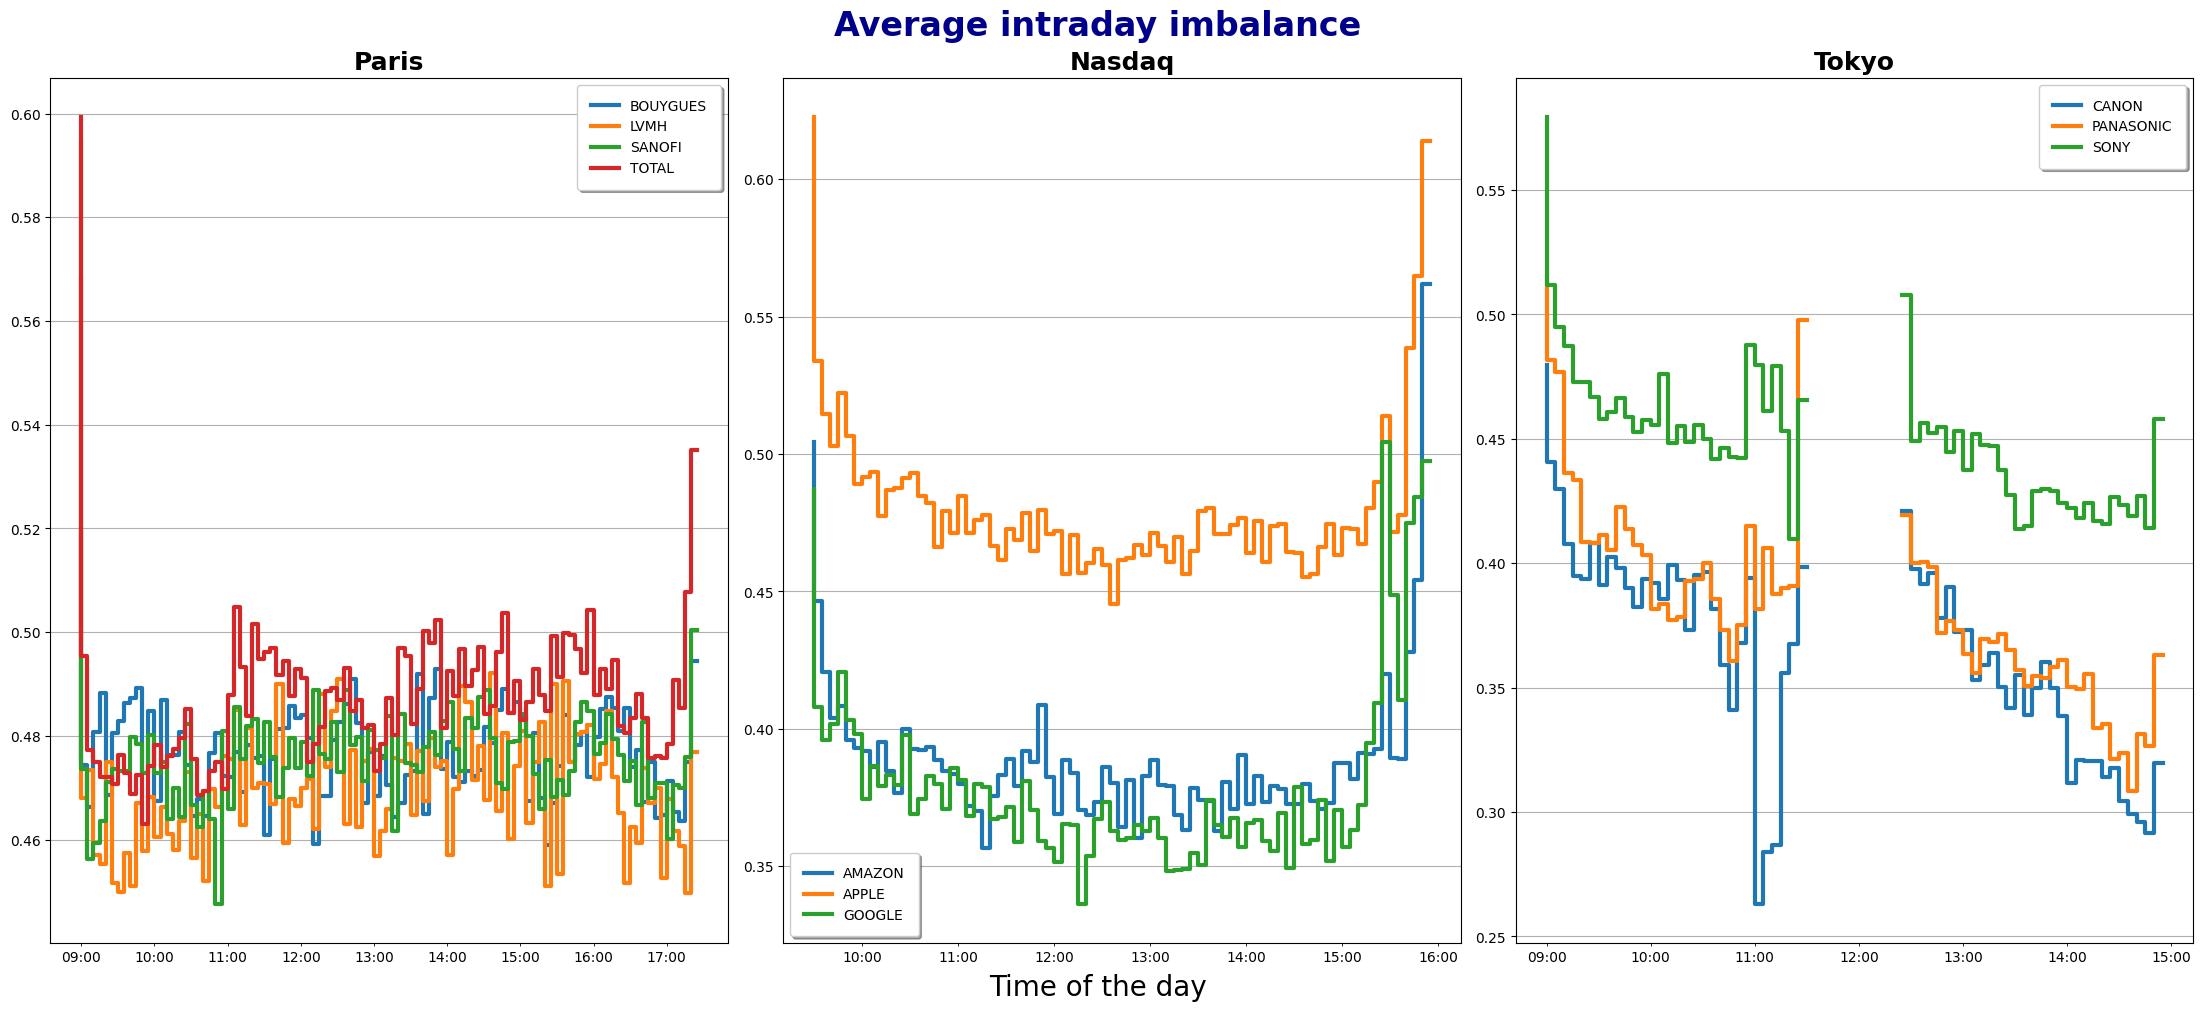

In [19]:
plotIntraday(IntradayCurvesImbalance(dfs,Locations.keys()),title="Average intraday imbalance", titley="")

**Remarks.**

It's clear to see that the imbalance is U-shaped, more pronounced at the start and end of the day. Once again, this is due to agents racing to execute their trades at the beginning and end of the day.

### 7. Best Limit Quantity Curves $Q_{ask}+Q_{bid}$

In [20]:
def IntradayCurvesBestLimitQty(dfs,locations):
    LimitQtys= {}
    for loc in locations :
        LimitQty = pd.DataFrame ({key: ( dfs[key].AskQty + dfs[key].BidQty ).resample('5T').sum().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1]) for key in Locations[loc]} )
        LimitQty = 100*LimitQty.groupby(LimitQty.index.time).mean()/ LimitQty.sum()
        LimitQtys[loc]=LimitQty
    return LimitQtys

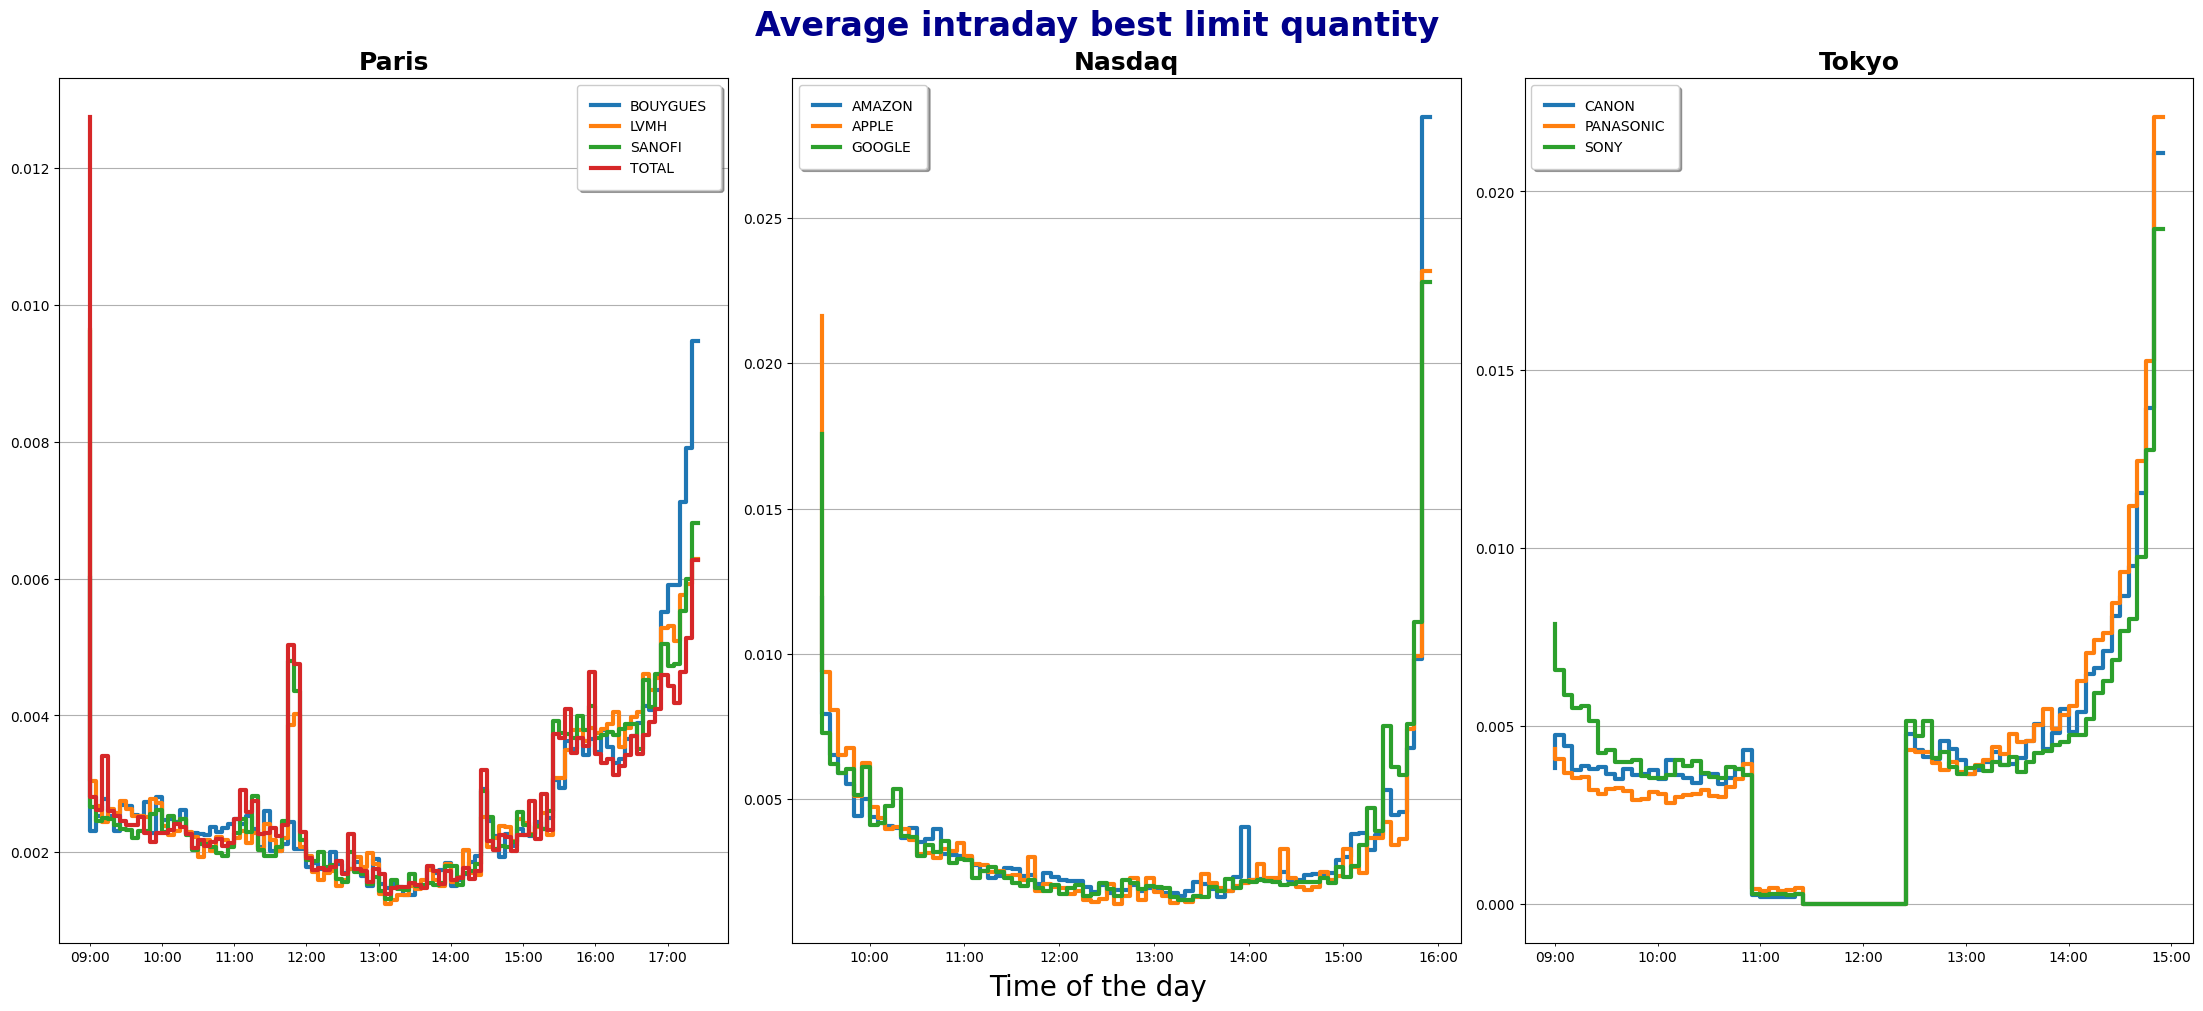

In [21]:
plotIntraday(IntradayCurvesBestLimitQty(dfs,Locations.keys()),title="Average intraday best limit quantity",titley="")

## III. Relationship between the different intraday indicators

We'll find the relationship between different intraday indicators using simple linear regressions :
* relationship between the volume and the number of trades, 
* between the turnovers and the number of trades, 
* between the volatility per trade and the bid-ask spread.

### 1. Relationship volumes/trades

In [22]:
def PerformRegression(x,y):
    M=len(x)
    xval=x.values.reshape((-1,1))
    yval=y.values
    
    model = LinearRegression().fit(xval,yval)
    r2 = model.score(xval, yval)
    response = model.predict(xval)
    s2=sum((yval - response)**2)/(M-2)
    
    mu_x=np.mean(x)
    sigma_x=np.std(x)
    
    minx = min(x)
    maxx = max(x)
    nfitx = 2000
    dx = (maxx-minx)/nfitx
    xfit = minx+dx*np.arange(0,nfitx)
    a=model.intercept_
    b=model.coef_[0]
    yfit = a+b*xfit
    yband = np.zeros(nfitx)
    xm=np.mean(x)
    ssxx=sum((x-xm)**2)
    # Pearson's formula for "Prediction Error"
    for n in range(0, nfitx):
        yband[n] = np.sqrt(s2*(1.0+1.0/M+(xfit[n]-xm)**2/ssxx))
    
    factor_68_to_90=scipy.stats.norm.isf(0.05)
    ylo = yfit - yband * factor_68_to_90
    yhi = yfit + yband * factor_68_to_90
    y1 = np.zeros((2, nfitx))
    y1[0, :] = ylo
    y1[1, :] = yhi
    
    return xval, response, xfit, y1, r2

    
def PlotRegression(dfx,dfy,title,titlex,titley):
    
    locs = list(Locations.keys())
            
    fig, axes = plt.subplots(1,3,figsize=(22, 10),constrained_layout=True)
    facecolour = 'mediumpurple'
    for i in range(len(locs)):
        
        data=pd.DataFrame({"x" : [], "y" : [], "Stock" : []})
        cols=dfx[locs[i]].columns
        n=len(dfx[locs[i]])
        
        for j in range(len(cols)):
            data=pd.concat( [ data, pd.DataFrame({ "x" : dfx[locs[i]][cols[j]], "y": dfy[locs[i]][cols[j]], "Stock" : [cols[j]]*n })])

        x = data["x"]
        y = data["y"]
        xval, response, xfit, y1, r2 = PerformRegression(x,y)
        line1,=axes[i].plot(xval, response, color='k', label='Droite de regression',linewidth=2)
        line2,=axes[i].plot(xfit, y1[0, :], '--',color=facecolour,label='Intervalle de prédiction à 95%',linewidth=2)
        line3,=axes[i].plot(xfit, y1[1, :], '--',color=facecolour,linewidth=2)
        axes[i].legend([line1,line2],['Droite de regression','Intervalle de prédiction à 95%'],loc='upper left',fancybox=True, framealpha=1, shadow=True, borderpad=1)
        axes[i].text(.4,0.05,'$R^2= %.2f$' % r2,horizontalalignment='center',transform=axes[i].transAxes,fontsize=18)
        for col in cols:
            tmp=data.loc[data.Stock == col]
            axes[i].scatter(tmp["x"],tmp["y"],alpha=1,edgecolor='k', label=col)
            
    for i in range(len(locs)) :
        axes[i].grid(False)
        axes[i].set_facecolor('xkcd:white')
        axes[i].set_title(locs[i], fontsize=18,fontweight='bold', color="k")
        axes[i].legend(fancybox=True, framealpha=1, shadow=True, borderpad=1)
        
        
            
    fig.suptitle(title, fontsize=24, color="darkblue",fontweight='bold')
    fig.supxlabel(titlex, fontsize=20)
    fig.supylabel(titley, fontsize=20)
    plt.show()
    

def PlotRegressionByStock(dfx,dfy,title,titlex,titley,removeOutliers=False,q=0.98,verbose=False):
    
    locs = list(Locations.keys())
            
    fig, axes = plt.subplots(1,3,figsize=(22, 10),constrained_layout=True)
    facecolour = 'mediumpurple'
    for i in range(len(locs)):
        
        data=pd.DataFrame({"x" : [], "y" : [], "Stock" : []})
        cols=dfx[locs[i]].columns
        n=len(dfx[locs[i]])
        
        if verbose:
            print("#####----------------------------- Location : {}------------------------------######".format(locs[i]))
        for j in range(len(cols)):
            data=pd.DataFrame({ "x" : dfx[locs[i]][cols[j]], "y": dfy[locs[i]][cols[j]], "Stock" : [cols[j]]*n })
            data[['x', 'y']] = data[['x', 'y']].fillna(data[['x', 'y']].mean())

            outliers=data.loc[(data.x >= data['x'].quantile(q)) & (data.y >= data['y'].quantile(q))]
            
            if removeOutliers:
                data=data.loc[(data.x < data['x'].quantile(q)) & (data.y < data['y'].quantile(q))]
            
            x = data["x"]
            y = data["y"]
            
            
            if verbose:
                print("{}% Outliers' found are : ".format(q*100))
                print("------------------------------ Stock : {}--------------------------------".format(cols[j]))
                print(outliers)
            
            
            xval, response, xfit, y1, r2 = PerformRegression(x,y)
            line1,=axes[i].plot(xval, response, label='Droite de regression',linewidth=2)
            axes[i].legend([line1],['Droite de regression'],loc='upper left',fancybox=True, framealpha=1, shadow=True, borderpad=1)
            axes[i].scatter(data["x"],data["y"],alpha=1,edgecolor='k', label=cols[j])
            
    for i in range(len(locs)) :
        axes[i].grid(False)
        axes[i].set_facecolor('xkcd:white')
        axes[i].set_title(locs[i], fontsize=18,fontweight='bold', color="k")
        axes[i].legend(fancybox=True, framealpha=1, shadow=True, borderpad=1)
        
        
            
    fig.suptitle(title, fontsize=24, color="darkblue",fontweight='bold')
    fig.supxlabel(titlex, fontsize=20)
    fig.supylabel(titley, fontsize=20)
    plt.show()
            
            

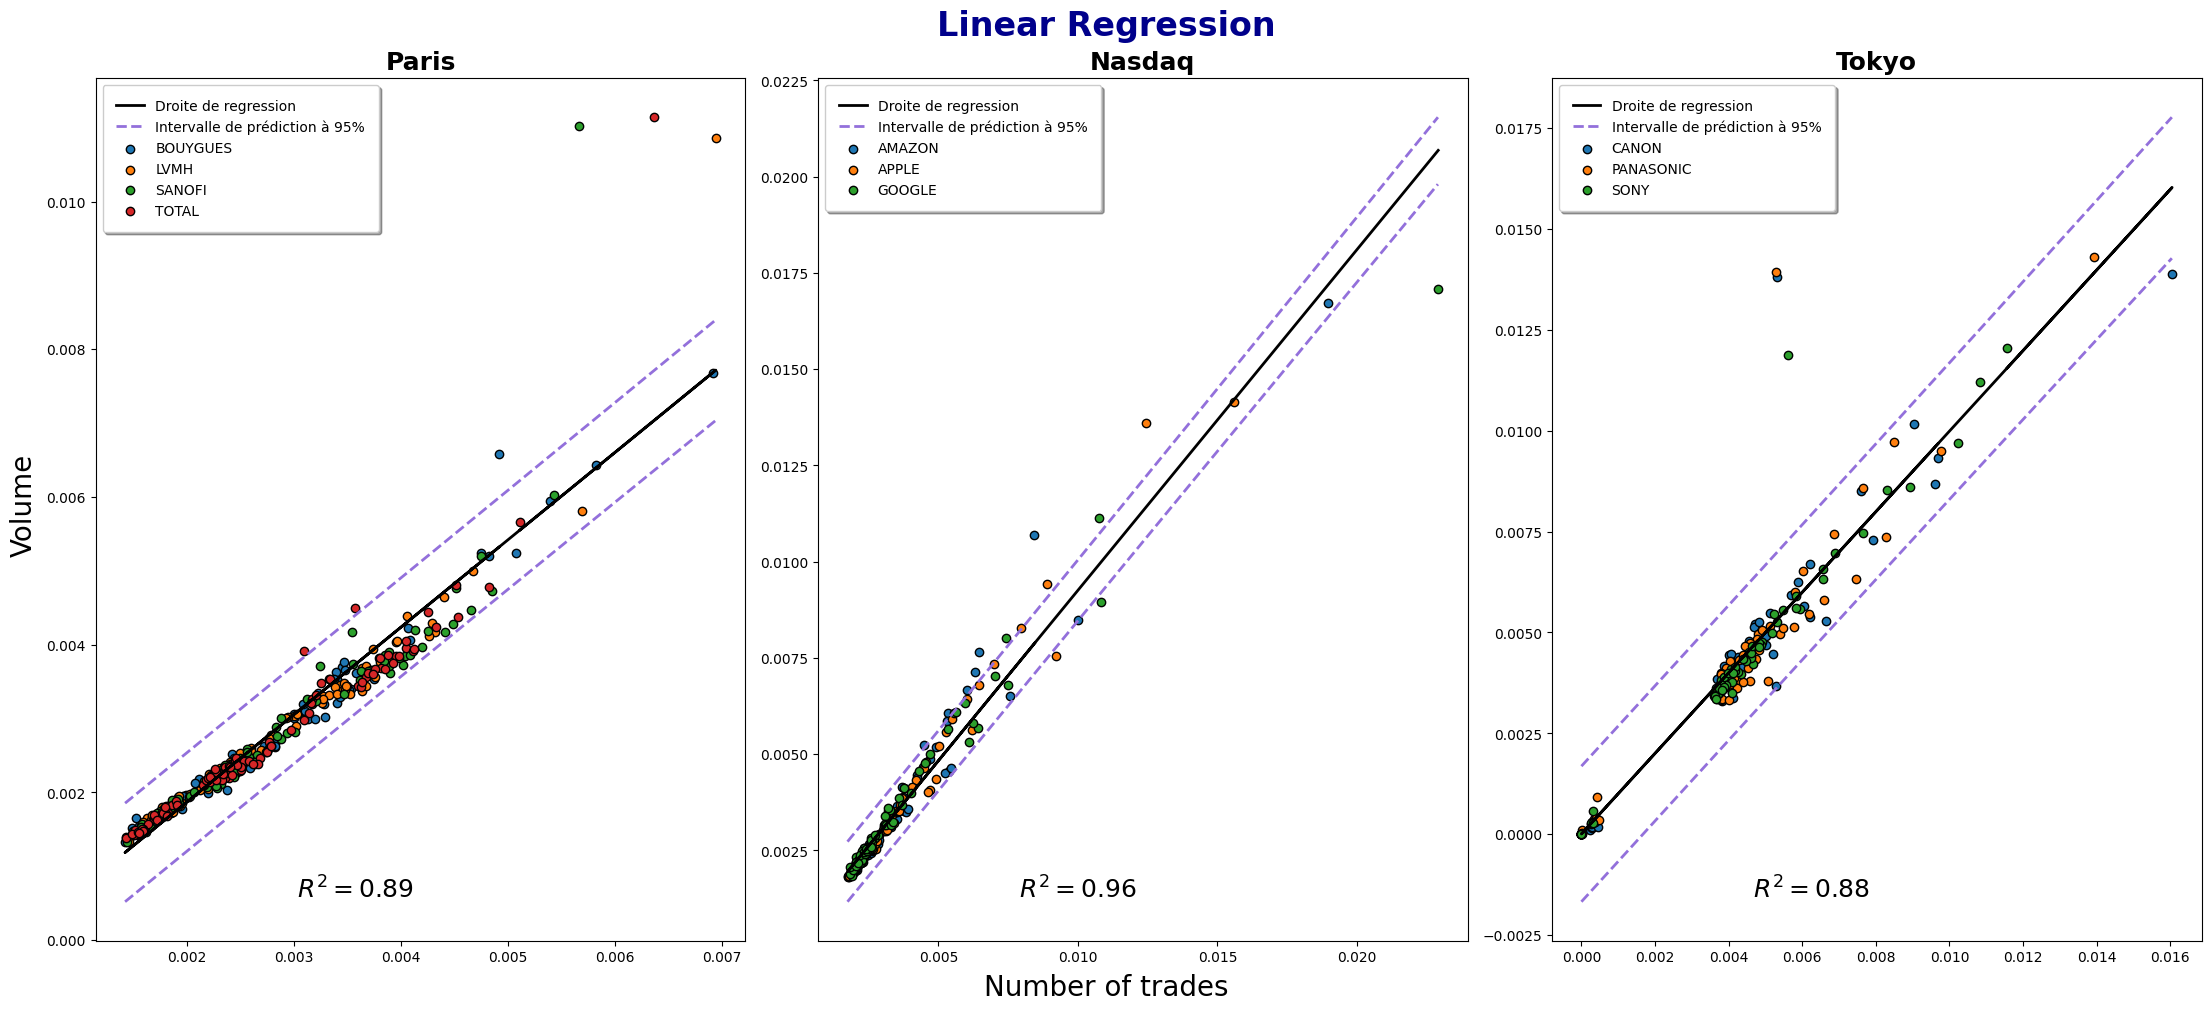

In [23]:
PlotRegression(IntradayCurvesNbTrades(dfs,Locations.keys()),IntradayCurvesVolume(dfs,Locations.keys()),title="Linear Regression",titlex="Number of trades",titley="Volume")

**Remark :**

The number of trades and volume are clearly linearly related. The large $R^2$ values close to 1 visible at the bottom of the figures confirm our assertion. Their ratio is used as a proxy for liquidity, the ATS (Average Trade Size).

### 2. Relationship turnovers/trades

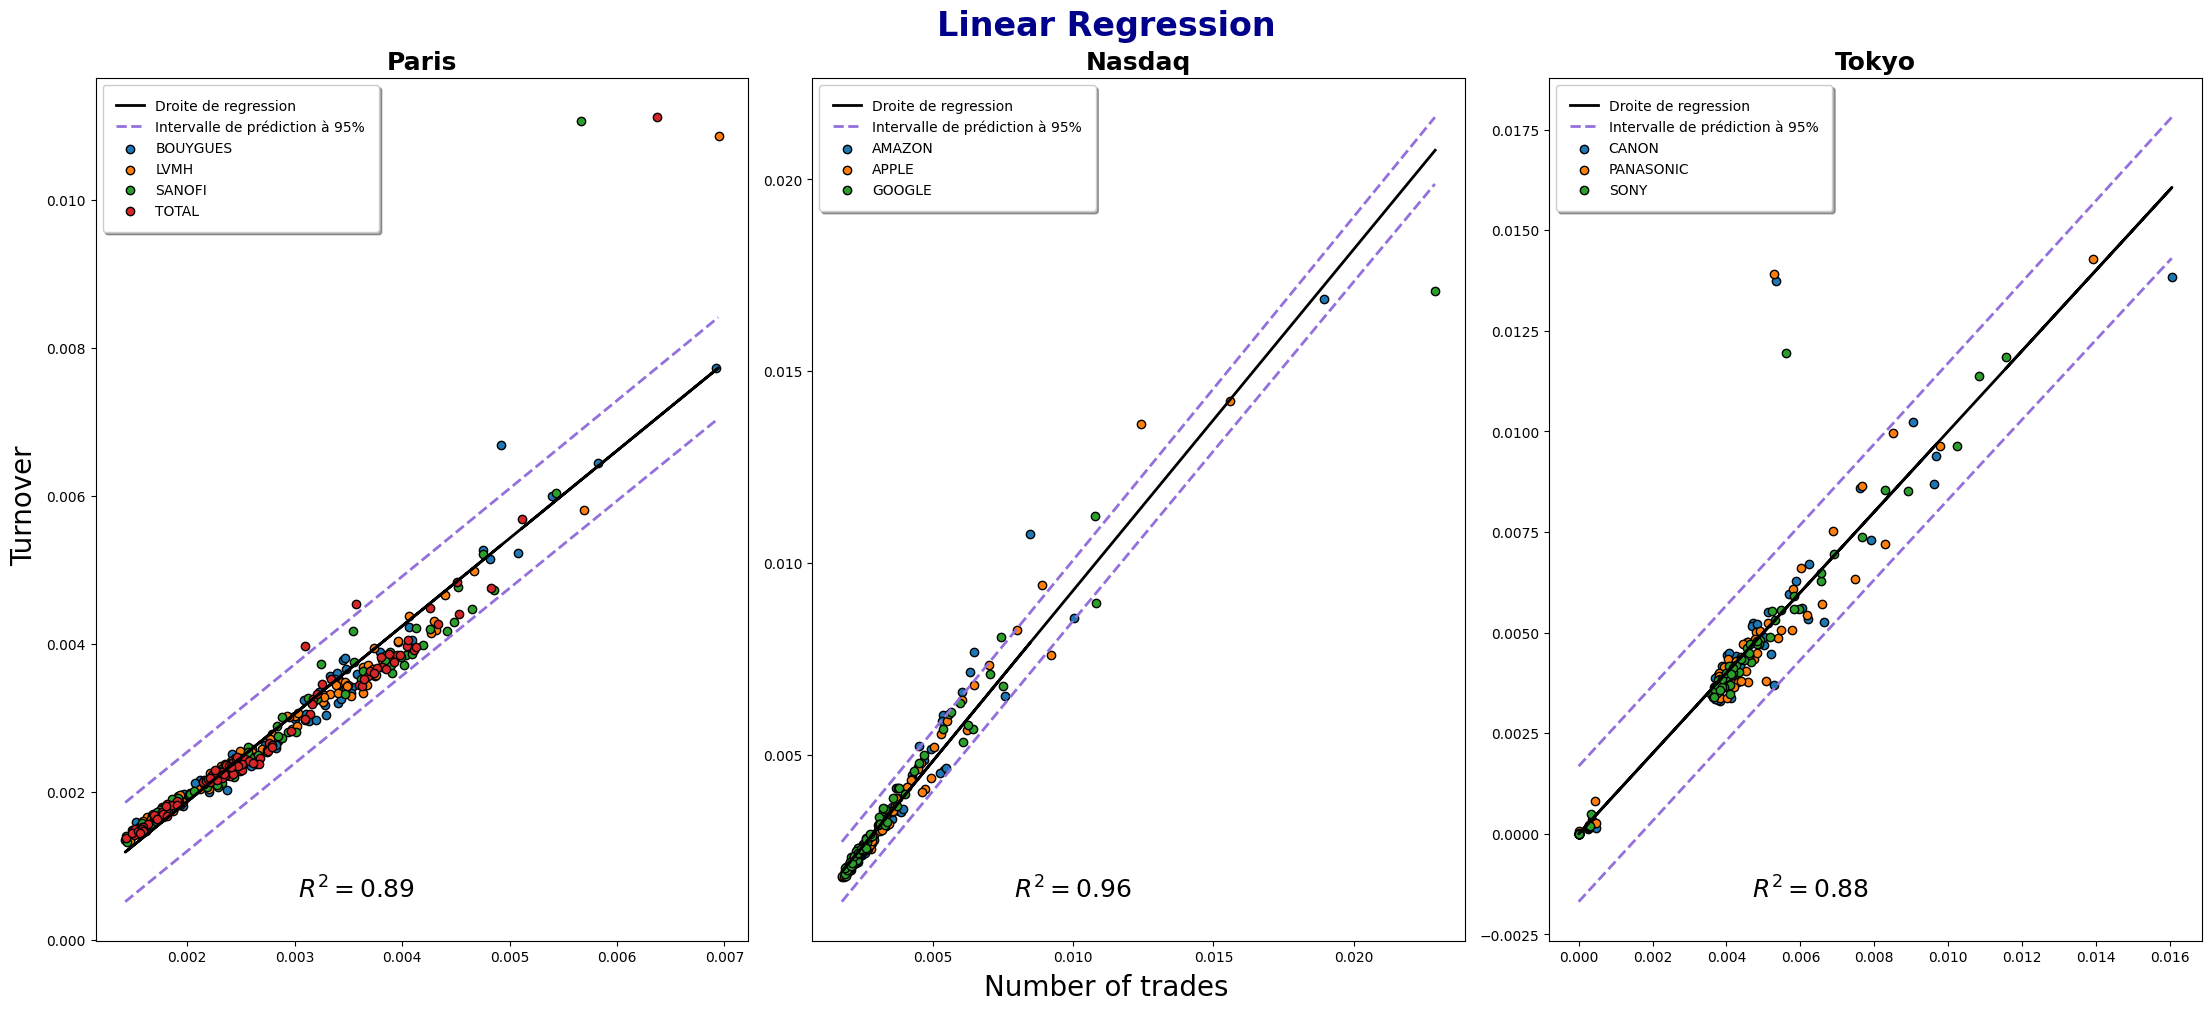

In [24]:
PlotRegression(IntradayCurvesNbTrades(dfs,Locations.keys()),IntradayCurvesTurnover(dfs,Locations.keys()),title="Linear Regression",titlex="Number of trades",titley="Turnover")

**Remark :**

The linearity between these two measures follows, given the linear relationship above. The result is ATT (Average Trade Turnover).

### 3. Relationship volatility per trade/bid-ask spread

Volatility can be seen as a measure of the amount of information contained in the price. In practice, this information is correlated with the order flow that anticipates or causes price movements.

It's well known that spread and volatility are intimately linked: while spread sets the profit per transaction for market makers, volatility determines the adverse selection they face.
In any model where market makers break even, there must be an equation fixing the relationship between bid-ask spread and volatility.

This relationship has been the subject of several models attempting to justify it at the microscopic level, since it is empirically observed in the data.

In the simplest possible model by Madhavan, Richardson and Roomans (MRR) in 1997, we obtain that
$$\varphi=c\sigma_{mid} N^{-1/2},$$
where $\varphi$ is the bid-ask spread, $\sigma_{mid}$ is the volatility of the mid price, $N$ is the number of transactions and $c>0$.

In [25]:
def IntradayCurvesVolatilityPerTrade(dfs,locations):
    VolatilityPerTrades= {}
    for loc in locations :
        Volatility = pd.DataFrame ({key: np.sqrt(((np.log(dfs[key].TradedPrice/dfs[key].TradedPrice.shift(1)))**2).resample('5T').sum().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1])) for key in Locations[loc]} )
        Nbtrade = pd.DataFrame ({key: dfs[key].TradedSign.abs().resample('5T').sum().between_time(OpenCloseTime[loc][0],OpenCloseTime[loc][1]) for key in Locations[loc]} )
        Volatility = 100*Volatility.groupby(Volatility.index.time).mean()
        Nbtrade = Nbtrade.groupby(Nbtrade.index.time).mean()
        VolatilityPerTrade = Volatility / np.sqrt(Nbtrade)           
        VolatilityPerTrades[loc] = VolatilityPerTrade
    return VolatilityPerTrades

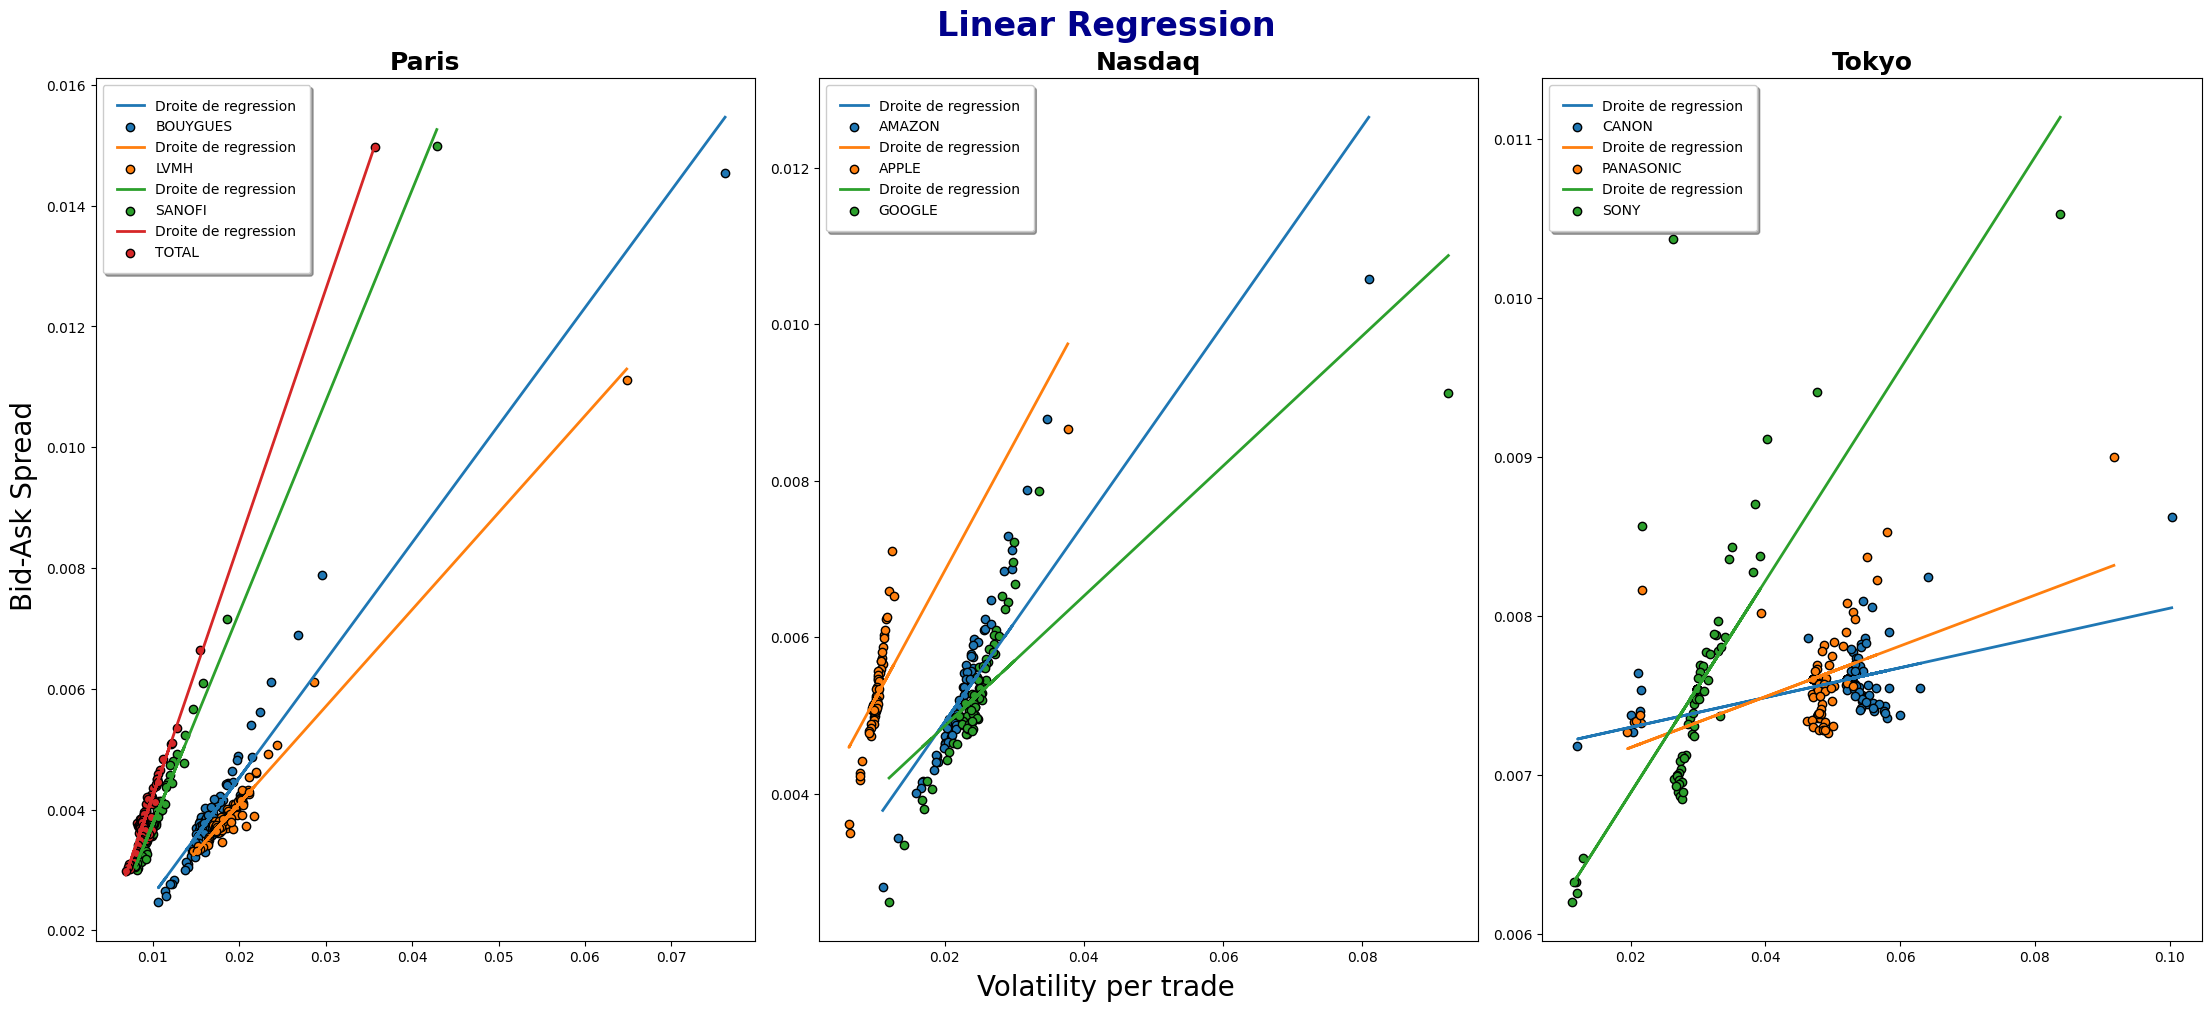

In [26]:
PlotRegressionByStock(IntradayCurvesVolatilityPerTrade(dfs,Locations.keys()),IntradayCurvesMeanSpread(dfs,Locations.keys()),title="Linear Regression",titlex="Volatility per trade",titley="Bid-Ask Spread")

#### Deleting the outliers ( the last 2% quantile )

#####----------------------------- Location : Paris------------------------------######
98.0% Outliers' found are : 
------------------------------ Stock : BOUYGUES--------------------------------
                 x         y     Stock
09:00:00  0.076201  0.014537  BOUYGUES
09:05:00  0.029631  0.007881  BOUYGUES
09:10:00  0.026841  0.006896  BOUYGUES
98.0% Outliers' found are : 
------------------------------ Stock : LVMH--------------------------------
                 x         y Stock
09:00:00  0.064823  0.011112  LVMH
09:05:00  0.028720  0.006120  LVMH
09:10:00  0.024406  0.005063  LVMH
98.0% Outliers' found are : 
------------------------------ Stock : SANOFI--------------------------------
                 x         y   Stock
09:00:00  0.042864  0.014996  SANOFI
09:05:00  0.018638  0.007162  SANOFI
09:10:00  0.015852  0.006092  SANOFI
98.0% Outliers' found are : 
------------------------------ Stock : TOTAL--------------------------------
                 x         y  Stock
09:00

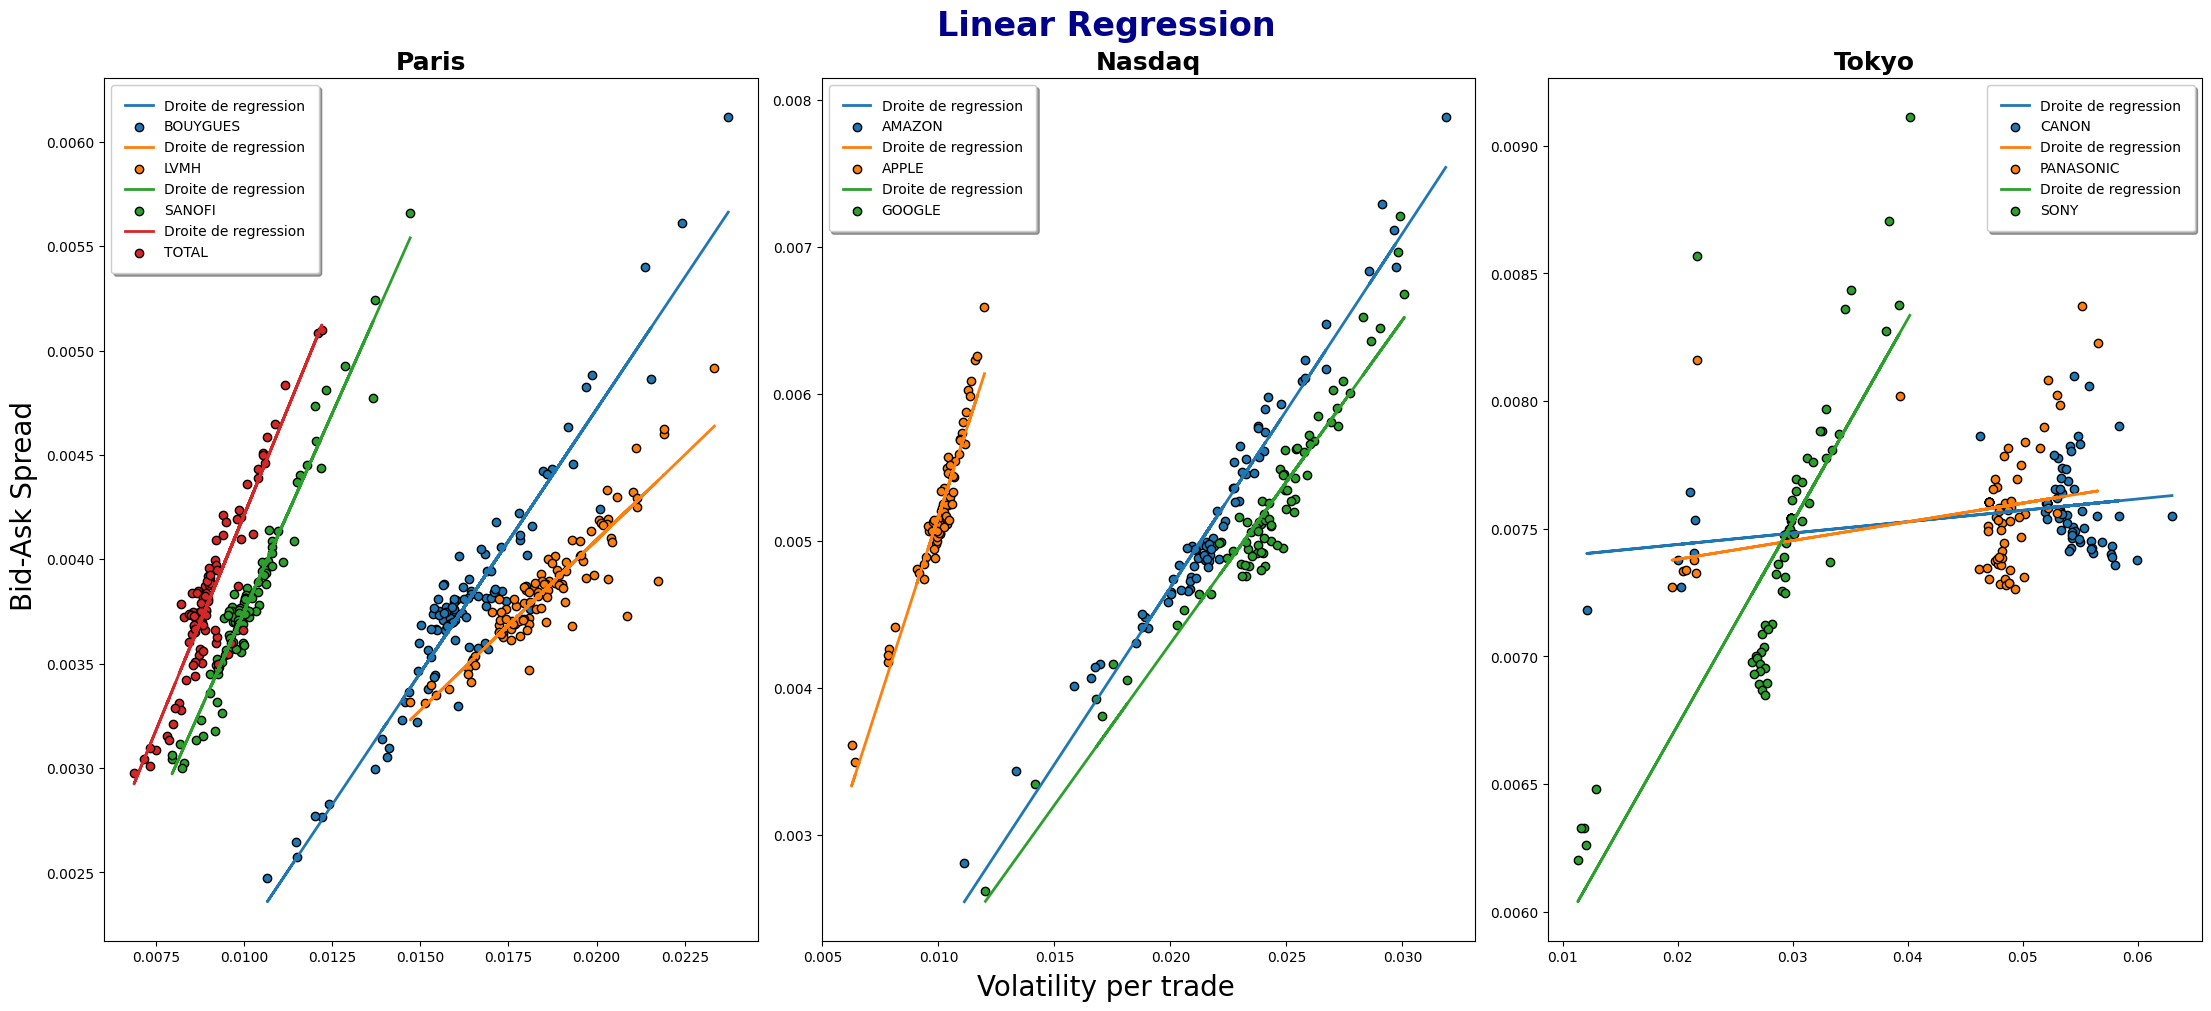

In [27]:
PlotRegressionByStock(IntradayCurvesVolatilityPerTrade(dfs,Locations.keys()),IntradayCurvesMeanSpread(dfs,Locations.keys()),title="Linear Regression",titlex="Volatility per trade",titley="Bid-Ask Spread",removeOutliers=True,verbose=True)

**Conclusion :**

According to the economist approach, market-makers receive spread remuneration in exchange for volatility risk, leading to a proportional relationship between spread and volatility, represented by $\varphi$ ∝ $\sigma$.

The MMR model, on the other hand, suggests that market-makers are more inclined to get rid of their inventory when N is large. They are remunerated according to the "unwinding risk" represented by $\sigma N^{-1/2}$, which implies a proportional relationship between spread and unwinding risk, represented by $\varphi$ ∝ $\sigma N^{-1/2}$.

However, as mentioned above, tick size plays a crucial role in this relationship. For large tick assets, such as TSE, the spread cannot tighten further as volatility decreases, making the relationship non-linear. On the other hand, for small tick assets, such as NY and Paris, the increased volatility of the median price allows greater mobility of assets on the tick grid, leading to an increase in the spread and a linear relationship as seen in the figures above.